In [89]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

In [90]:
file = "C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\VNA\\S21_Malaysia_readout_260624_-15dBm_36dB_atten.csv"

data = pd.read_csv(file)

freqs = data['FREQ1.GHZ']
mags = 10**(data['LOGMAG1']/20)
phase = data['PHASE2.DEG']

print(data)

       PNT  FREQ1.GHZ   LOGMAG1  FREQ2.GHZ  PHASE2.DEG
0        1     7.4000 -71.55153     7.4000    77.78776
1        2     7.4002 -71.67670     7.4002    77.44680
2        3     7.4004 -71.59418     7.4004    77.37218
3        4     7.4006 -71.71994     7.4006    78.39764
4        5     7.4008 -71.55151     7.4008    79.27624
...    ...        ...       ...        ...         ...
996    997     7.5992 -73.68747     7.5992   -67.93726
997    998     7.5994 -73.65093     7.5994   -66.71273
998    999     7.5996 -73.53291     7.5996   -67.36903
999   1000     7.5998 -73.63460     7.5998   -68.16496
1000  1001     7.6000 -73.60134     7.6000   -67.85563

[1001 rows x 5 columns]


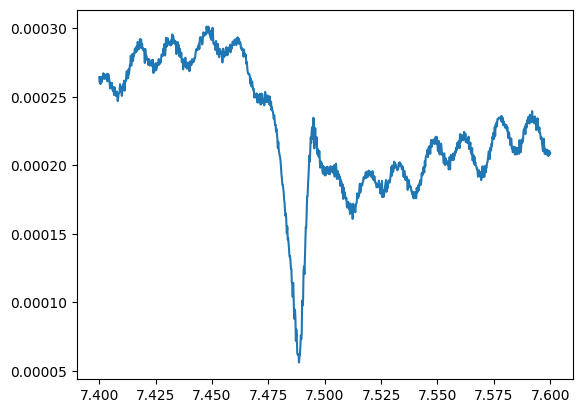

In [91]:
plt.plot(freqs, mags)

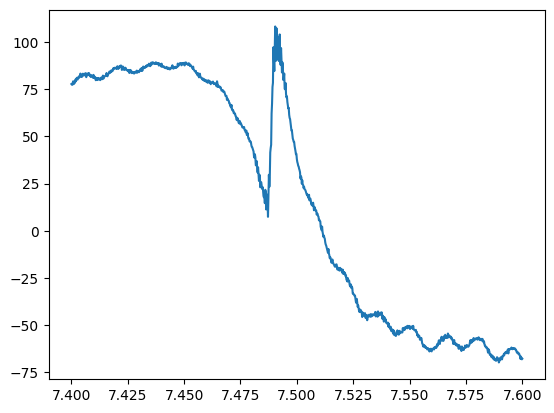

In [92]:
# cut = 445
# phase[cut:] -= 90
plt.plot(freqs, phase)

In [93]:
def lorentzian(x, x0, A, B, gamma):
    """
    x: Independent variable
    x0: Center of the peak
    A: Amplitude (maximum height)
    gamma: Half-Width at Half-Maximum (HWHM)
    """
    return A * (gamma**2) / ((x - x0)**2 + gamma**2) + B

In [94]:
p0_x0 = freqs[np.argmin(mags)]  # Find X value where Y is maximum
p0_A = -12              # Find maximum Y value
p0_B = -72
p0_gamma = 0.01                     # Initial guess for HWHM
initial_guess = [p0_x0, p0_A, p0_B, p0_gamma]
print(initial_guess)

popt, pcov = sp.optimize.curve_fit(lorentzian, freqs, mags, p0=initial_guess)

x0_opt, A_opt, B_opt, gamma_opt = popt
errors = np.sqrt(np.diag(pcov))

print(f"Match Results:")
print(f"Center (x0): {x0_opt:.3f} ± {errors[0]:.3f}")
print(f"Amplitude (A): {A_opt:.3f} ± {errors[1]:.3f}")
print(f"Baseline (B): {B_opt:.3f} ± {errors[2]:.3f}")
print(f"HWHM (gamma): {gamma_opt:.3f} ± {errors[3]:.3f}")

fit_label = f"""
Fit Lorentzian
omega_0: {x0_opt:.3e} GHz
Amplitude (A): {A_opt:.3e}
Baseline (B): {B_opt:.3e}
HWHM: {gamma_opt*1000:.3f} MHz
"""

[np.float64(7.4886), -12, -72, 0.01]
Match Results:
Center (x0): 7.488 ± 0.000
Amplitude (A): -0.000 ± 0.000
Baseline (B): 0.000 ± 0.000
HWHM (gamma): 0.004 ± 0.000


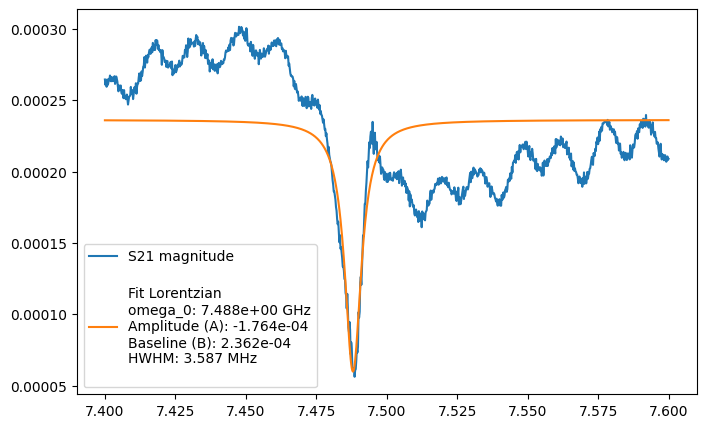

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(freqs, mags, label="S21 magnitude")
plt.plot(freqs, lorentzian(freqs, *popt), label=fit_label)
plt.legend()